<a href="https://colab.research.google.com/github/Tapopita/Desafio-1-ciencia-de-datos/blob/main/Desafio_1_ciencia_de_datos_Carlos_Aravena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:

import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [72]:
tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

1. Análisis de facturación

In [73]:
facturacion = {}

for nombre, df in tiendas.items():
    total = df["Precio"].sum()
    facturacion[nombre] = total
    print(f"{nombre}: ${total:,.2f}")

Tienda 1: $1,150,880,400.00
Tienda 2: $1,116,343,500.00
Tienda 3: $1,098,019,600.00
Tienda 4: $1,038,375,700.00


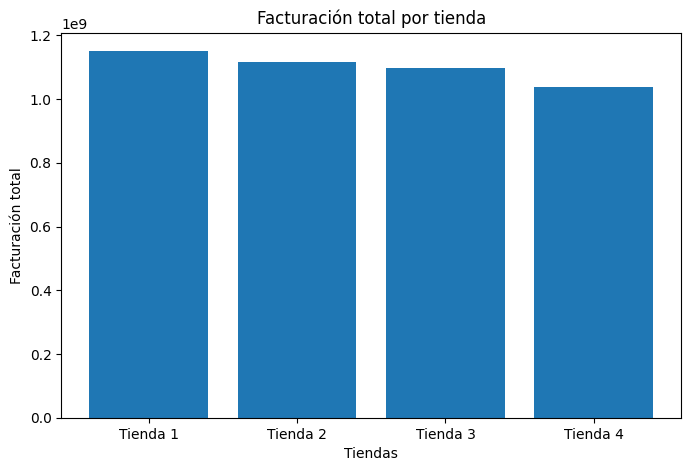

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(facturacion.keys(), facturacion.values())
plt.title("Facturación total por tienda")
plt.xlabel("Tiendas")
plt.ylabel("Facturación total")
plt.show()

2. Ventas por categoría

In [75]:
for nombre, df in tiendas.items():
    print(f"\nVentas por categoría en {nombre}:")
    print(df["Categoría del Producto"].value_counts())


Ventas por categoría en Tienda 1:
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

Ventas por categoría en Tienda 2:
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

Ventas por categoría en Tienda 3:
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: count, dtype: int64

Ven

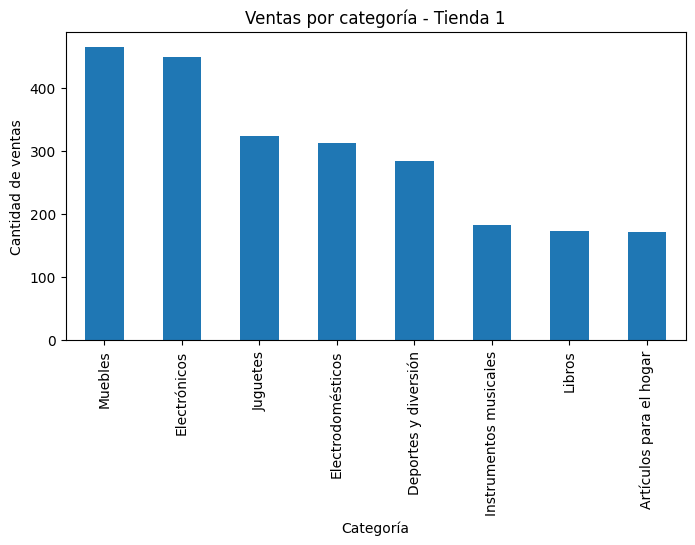

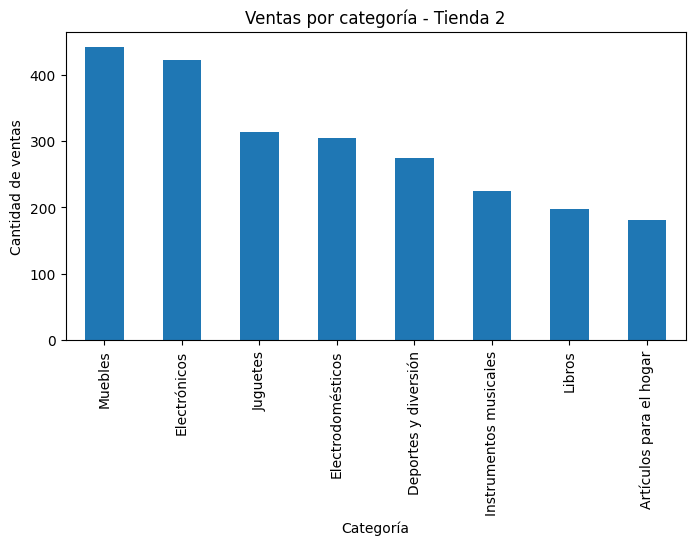

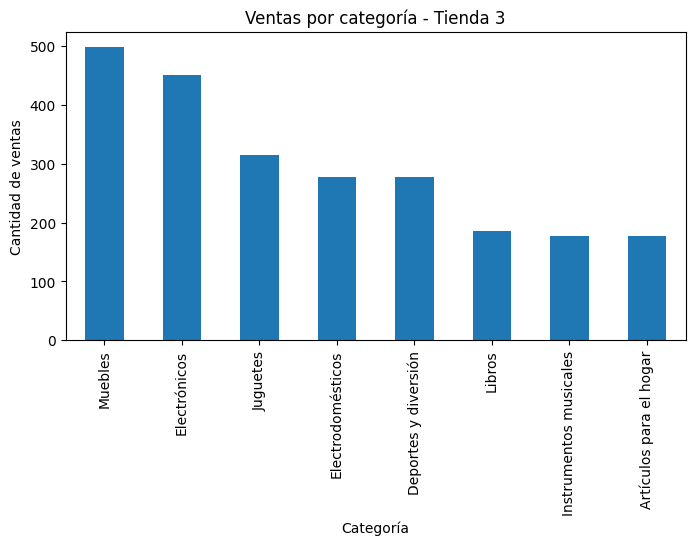

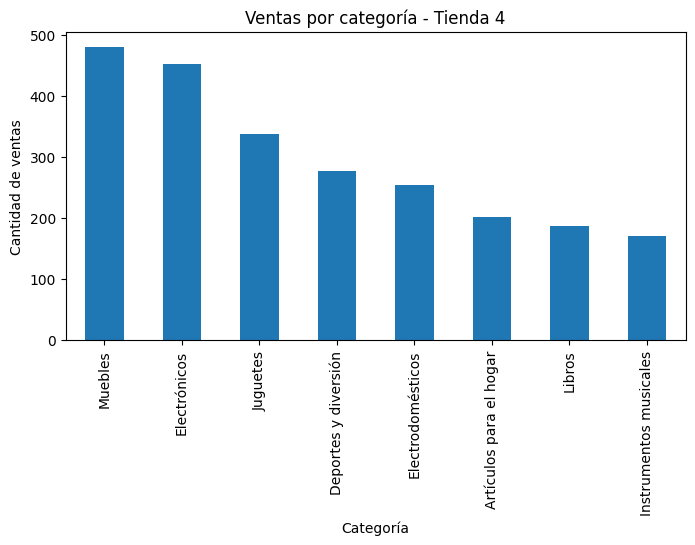

In [76]:
for nombre, df in tiendas.items():
    categorias = df["Categoría del Producto"].value_counts()

    plt.figure(figsize=(8,4))
    categorias.plot(kind="bar")
    plt.title(f"Ventas por categoría - {nombre}")
    plt.xlabel("Categoría")
    plt.ylabel("Cantidad de ventas")
    plt.show()

3. Calificación promedio de la tienda

In [77]:
calificaciones = {}

for nombre, df in tiendas.items():
    promedio = df["Calificación"].mean()
    calificaciones[nombre] = promedio
    print(f"{nombre}: {promedio:.2f}")

Tienda 1: 3.98
Tienda 2: 4.04
Tienda 3: 4.05
Tienda 4: 4.00


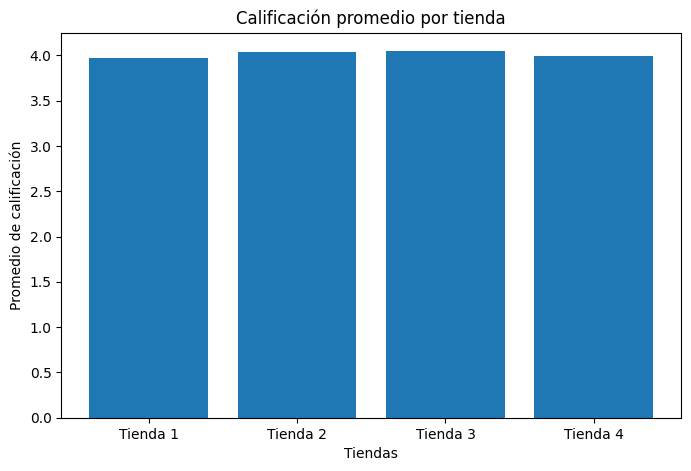

In [78]:
plt.figure(figsize=(8,5))
plt.bar(calificaciones.keys(), calificaciones.values())
plt.title("Calificación promedio por tienda")
plt.xlabel("Tiendas")
plt.ylabel("Promedio de calificación")
plt.show()

4. Productos más y menos vendidos

In [79]:
for nombre, df in tiendas.items():
    conteo_productos = df["Producto"].value_counts()

    producto_mas_vendido = conteo_productos.idxmax()
    producto_menos_vendido = conteo_productos.idxmin()

    print(f"\n{nombre}")
    print(f"Producto más vendido: {producto_mas_vendido}")
    print(f"Producto menos vendido: {producto_menos_vendido}")


Tienda 1
Producto más vendido: Microondas
Producto menos vendido: Auriculares con micrófono

Tienda 2
Producto más vendido: Iniciando en programación
Producto menos vendido: Juego de mesa

Tienda 3
Producto más vendido: Kit de bancas
Producto menos vendido: Bloques de construcción

Tienda 4
Producto más vendido: Cama box
Producto menos vendido: Guitarra eléctrica


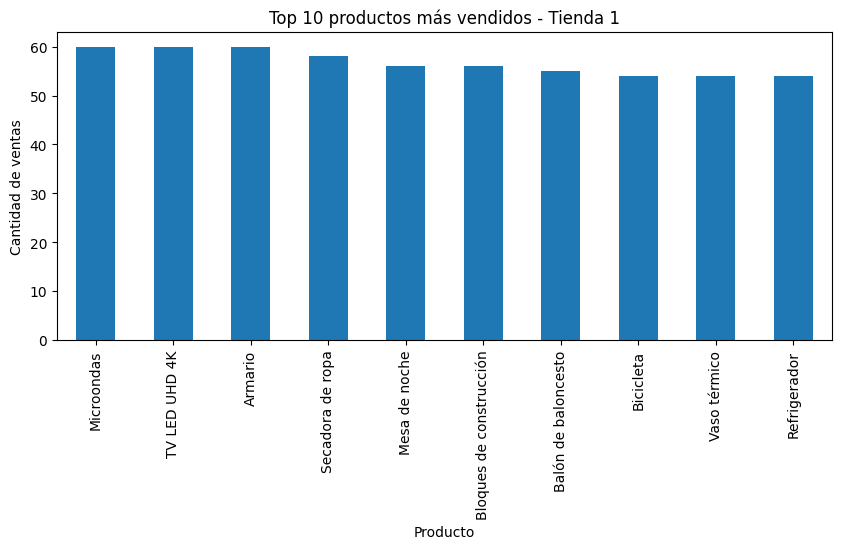

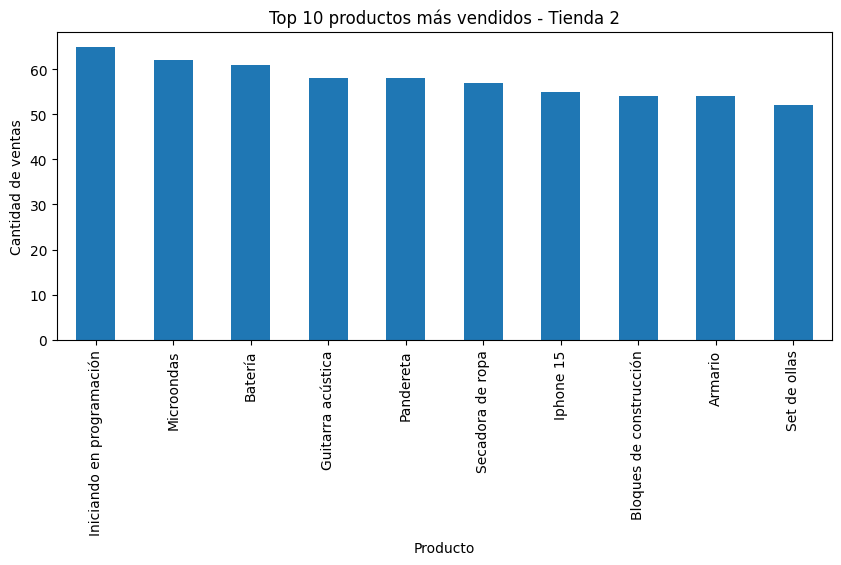

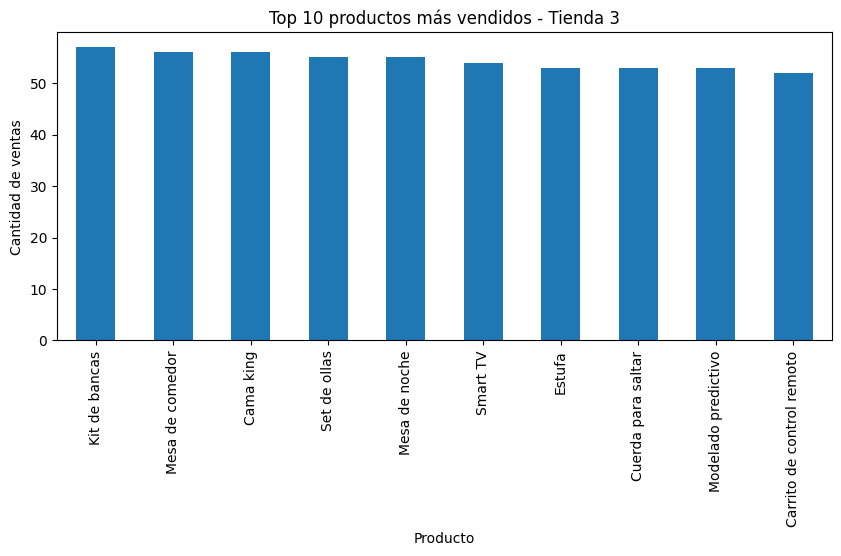

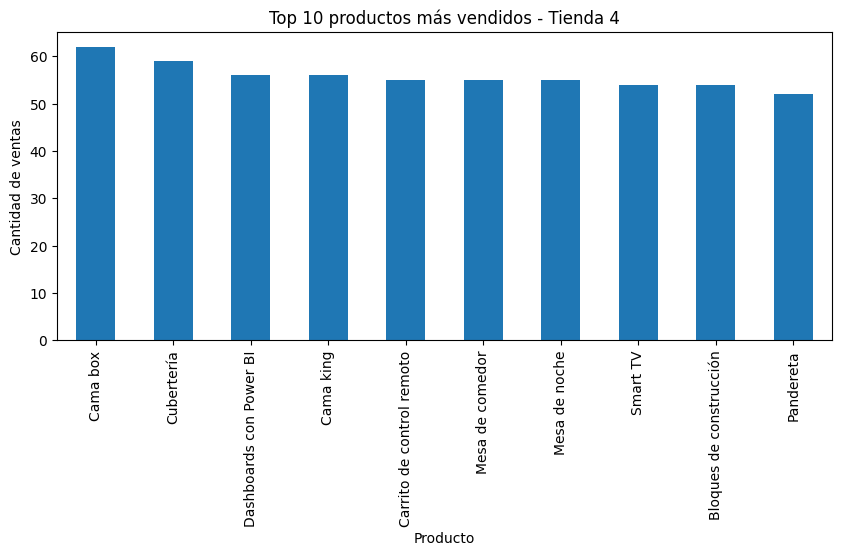

In [80]:
for nombre, df in tiendas.items():
    top_10 = df["Producto"].value_counts().head(10)

    plt.figure(figsize=(10,4))
    top_10.plot(kind="bar")
    plt.title(f"Top 10 productos más vendidos - {nombre}")
    plt.xlabel("Producto")
    plt.ylabel("Cantidad de ventas")
    plt.show()

5. Envío promedio por tienda

In [81]:
envios = {}

for nombre, df in tiendas.items():
    promedio_envio = df["Costo de envío"].mean()
    envios[nombre] = promedio_envio
    print(f"{nombre}: ${promedio_envio:,.2f}")

Tienda 1: $26,018.61
Tienda 2: $25,216.24
Tienda 3: $24,805.68
Tienda 4: $23,459.46


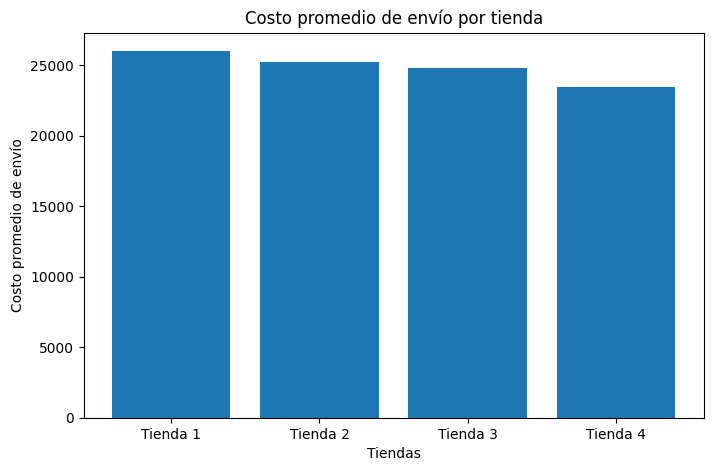

In [82]:
plt.figure(figsize=(8,5))
plt.bar(envios.keys(), envios.values())
plt.title("Costo promedio de envío por tienda")
plt.xlabel("Tiendas")
plt.ylabel("Costo promedio de envío")
plt.show()

6. Resumen comparativo

In [83]:
resumen_numerico = pd.DataFrame({
    "Facturación Total": facturacion,
    "Calificación Promedio": calificaciones,
    "Costo Promedio Envío": envios
})

display(
    resumen_numerico.style.format({
        "Facturación Total": "${:,.2f}",
        "Calificación Promedio": "{:.2f}",
        "Costo Promedio Envío": "${:,.2f}"
    })
)

,Facturación Total,Calificación Promedio,Costo Promedio Envío
Tienda 1,"$1,150,880,400.00",3.98,"$26,018.61"
Tienda 2,"$1,116,343,500.00",4.04,"$25,216.24"
Tienda 3,"$1,098,019,600.00",4.05,"$24,805.68"
Tienda 4,"$1,038,375,700.00",4.00,"$23,459.46"


7. Selección de tienda a vender e informe final

In [84]:
# Identificar tienda con menor facturación
tienda_a_vender = resumen_numerico["Facturación Total"].idxmin()

# Mostrar la tabla resumen
display(resumen_numerico)

,Facturación Total,Calificación Promedio,Costo Promedio Envío
Tienda 1,1.150880e+09,3.976685,26018.609580
Tienda 2,1.116344e+09,4.037304,25216.235693
Tienda 3,1.098020e+09,4.048326,24805.680373
Tienda 4,1.038376e+09,3.995759,23459.457167


In [85]:
# Identificar tienda con menor facturación
tienda_a_vender = resumen_numerico["Facturación Total"].idxmin()

print("La tienda recomendada para vender es:", tienda_a_vender)

La tienda recomendada para vender es: Tienda 4


In [86]:
print(f"""
INFORME FINAL

Con el objetivo de apoyar la toma de decisiones del señor Juan, se realizó un análisis
comparativo del desempeño de las cuatro tiendas de Alura Store considerando cinco criterios:
facturación total, ventas por categoría, calificación promedio de los clientes,
productos más y menos vendidos y costo promedio de envío.

A partir del análisis de facturación se observó que la tienda con menor ingreso total es
{tienda_a_vender}. Este indicador es especialmente relevante, ya que la facturación refleja
la capacidad de generación de ingresos de cada tienda.

También se revisaron las categorías más vendidas y los productos con mayor rotación en cada tienda.
Sin embargo, el desempeño comercial de {tienda_a_vender} continúa siendo inferior al de las demás
tiendas evaluadas.

En cuanto a la calificación promedio de los clientes y al costo promedio de envío, aunque se
identificaron algunas diferencias entre tiendas, estos factores no logran compensar el menor
rendimiento observado en la facturación total.

CONCLUSIÓN

Considerando todos los criterios analizados, se recomienda al señor Juan vender
{tienda_a_vender}, ya que es la tienda que presenta el menor desempeño general
entre las cuatro evaluadas. Esta decisión permitiría liberar recursos para invertir
en un nuevo negocio con mayor potencial de crecimiento y rentabilidad.
""")


INFORME FINAL

Con el objetivo de apoyar la toma de decisiones del señor Juan, se realizó un análisis
comparativo del desempeño de las cuatro tiendas de Alura Store considerando cinco criterios:
facturación total, ventas por categoría, calificación promedio de los clientes,
productos más y menos vendidos y costo promedio de envío.

A partir del análisis de facturación se observó que la tienda con menor ingreso total es
Tienda 4. Este indicador es especialmente relevante, ya que la facturación refleja
la capacidad de generación de ingresos de cada tienda.

También se revisaron las categorías más vendidas y los productos con mayor rotación en cada tienda.
Sin embargo, el desempeño comercial de Tienda 4 continúa siendo inferior al de las demás
tiendas evaluadas.

En cuanto a la calificación promedio de los clientes y al costo promedio de envío, aunque se
identificaron algunas diferencias entre tiendas, estos factores no logran compensar el menor
rendimiento observado en la facturación to